# Embeddings with the released AstroCLIP spectrum encoder

[AstroCLIP](https://github.com/PolymathicAI/AstroCLIP) (Parker et al. 2024,
https://doi.org/10.1093/mnras/stae1450) CLIP-aligns a 302M-parameter DINOv2
image encoder with a 43M-parameter SpecFormer spectrum encoder into one
shared 1024-dimensional embedding space. The full cross-modal model is too
large and dependency-heavy to reimplement natively in `astrospec` (see
`astrospec/pretrained/astroclip.py`), so this notebook uses the released
`astroclip.ckpt` checkpoint through the `astroclip` package directly, calling
`model(spectrum, input_type="spectrum")` to get the aligned **spectrum**
embedding, then running the same cosine-similarity nearest-neighbour search
as `specformer_pretrained_similarity_search.ipynb`, the spectrum-side
counterpart to AstroLens's `astroclip_similarity_search.ipynb`, which does
the same thing on the image side.

`astrospec.pretrained.load_pretrained_specformer` (used in
`specformer_pretrained_similarity_search.ipynb`) loads the same checkpoint's
spectrum weights into `astrospec`'s own lightweight `SpecFormer`, with no
extra dependencies, the right choice for most uses. This notebook instead
runs the full published `AstroClipModel`, which is the only way to reach the
embedding space AstroCLIP actually CLIP-aligned against images, at the cost
of the `astroclip` package and its `dinov2` dependency.

AstroCLIP's spectrum tower was trained on DESI EDR spectra on their native
3,600-9,824 A, 0.80 A/pix grid (7,781 pixels); `utils/desi.py` reads that
grid directly, from a local MultimodalUniverse HDF5 tree if
`ASTROSPEC_DESI_ROOT` is set, otherwise streaming
[`MultimodalUniverse/desi`](https://huggingface.co/datasets/MultimodalUniverse/desi)
from the Hub. `SpecFormer.preprocess` (inside the `astroclip` package)
handles standardization and slicing into patches internally, so no
`astrospec.data.Patchify` is needed here.

## Install example-only dependencies

Not part of AstroSpec's core install; only needed for this example.
`astroclip` and its `dinov2` dependency both require `--no-deps` git
installs (see the [AstroCLIP README](https://github.com/PolymathicAI/AstroCLIP#installation)),
so they can't be folded into a single `pip install astrospec[astroclip]`.

In [1]:
!pip install -q h5py datasets matplotlib "astrospec[astroclip]"
!pip install -q --no-deps git+https://github.com/facebookresearch/dinov2.git@2302b6bf46953431b969155307b9bed152754069
!pip install -q --no-deps git+https://github.com/PolymathicAI/AstroCLIP.git

## Imports

In [2]:
import numpy as np
import torch
import torch.nn.functional as F

from astrospec.pretrained import load_pretrained_astroclip
from utils import desi

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load the pretrained AstroCLIP model

Downloads the released checkpoint once (cached by `huggingface_hub`
afterwards) and restores the full `AstroClipModel`, including both encoders, the
cross-attention projection heads, everything needed to reach the space the
paper's image-spectrum retrieval numbers were measured in.

In [3]:
model = load_pretrained_astroclip(device=device)
sum(p.numel() for p in model.parameters())

/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'image_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['image_encoder'])`.
/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'spectrum_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['spectrum_encoder'])`.


370798358

## Load spectra

2,000 spectra with their pipeline redshifts, on DESI's native pixel grid, no
resampling needed.

In [4]:
flux, z = desi.load_spectra(2000, redshift=True)
flux = desi.standardize(flux)
flux.shape, z.min(), z.max()

((2000, 7781), np.float32(-0.0021135716), np.float32(5.807099))

## Embed and search for nearest neighbours

`model(x, input_type="spectrum")` wants a `(B, L, 1)` tensor. The trailing
channel dimension `SpecFormer.preprocess` slices into patches internally
and returns one 1024-d embedding per spectrum directly, no pooling needed.
As in `specformer_pretrained_similarity_search.ipynb`, embeddings are
centered before the cosine so the shared common component does not dominate
every score. Redshift, which the model never sees, checks whether nearby
embeddings are physically similar; random pairs are the baseline.

In [5]:
@torch.no_grad()
def embed(flux):
    out = []
    for i in range(0, len(flux), 64):
        x = torch.from_numpy(flux[i : i + 64]).unsqueeze(-1).to(device)
        out.append(model(x, input_type="spectrum").cpu())
    return torch.cat(out)

pooled = embed(flux)
embeddings = F.normalize(pooled - pooled.mean(0, keepdim=True), dim=-1)

similarity = embeddings @ embeddings.T
similarity.fill_diagonal_(-1)
best = similarity.max(-1)
neighbour, neighbour_score = best.indices.numpy(), best.values.numpy()

rng = np.random.default_rng(0)
shuffled = rng.permutation(len(z))
random_score = (embeddings * embeddings[shuffled]).sum(-1).numpy()

print(f"{'':>17}  {'cosine':>8}  {'median |dz|':>12}  {'|dz| < 0.01':>12}")
for name, score, delta in [
    ("nearest neighbour", neighbour_score, np.abs(z - z[neighbour])),
    ("random pair", random_score, np.abs(z - z[shuffled])),
]:
    print(
        f"{name:>17}  {np.median(score):8.3f}  {np.median(delta):12.4f}"
        f"  {(delta < 0.01).mean():11.1%}"
    )

                     cosine   median |dz|   |dz| < 0.01
nearest neighbour     0.874        0.0610        30.5%
      random pair    -0.002        0.5851         2.8%


## A query and its three nearest neighbours

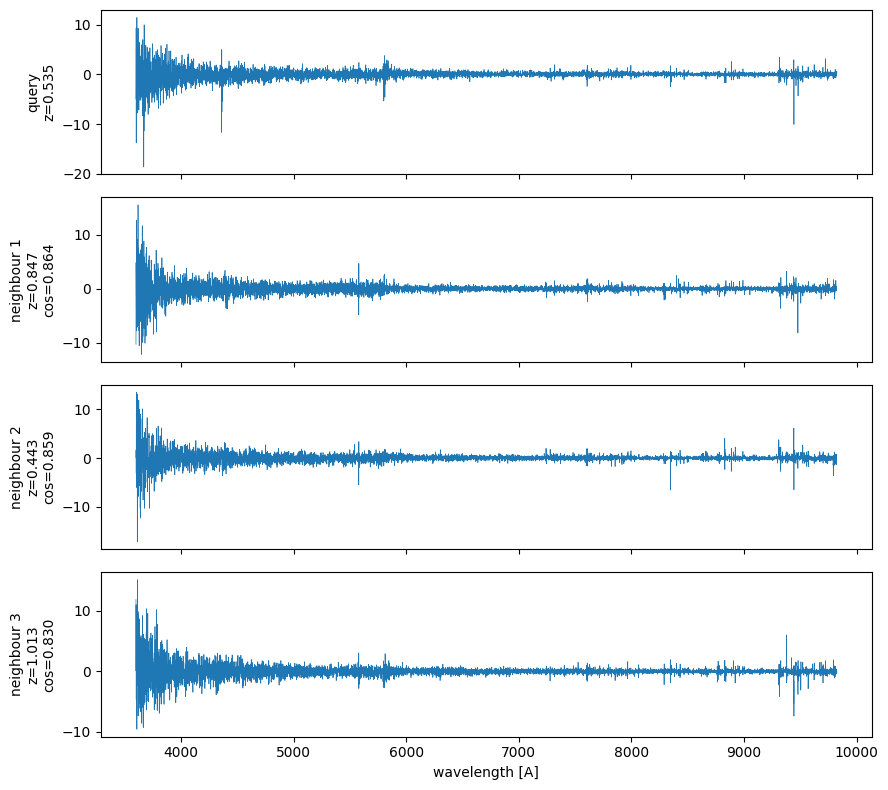

In [6]:
import matplotlib.pyplot as plt

grid = np.linspace(3600.0, 9824.0, flux.shape[-1])
query = int(np.argmax(z > 0.3))
top = similarity[query].topk(3)
panels = [(query, "query", None)] + [
    (int(i), f"neighbour {k + 1}", float(s))
    for k, (i, s) in enumerate(zip(top.indices, top.values))
]

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, (i, title, score) in zip(axes, panels):
    ax.plot(grid, flux[i], lw=0.5)
    label = f"{title}\nz={z[i]:.3f}"
    ax.set_ylabel(label if score is None else f"{label}\ncos={score:.3f}")
axes[-1].set_xlabel("wavelength [A]")
fig.tight_layout()

## Notes

This is the true spectrum-side embedding AstroCLIP was trained to produce,
CLIP-aligned against the image encoder in `AstroLens/examples/astroclip_similarity_search.ipynb`,
in principle, an image embedding and a spectrum embedding of the same object
should land close together in this same space, which neither notebook tests
on its own. Compare the retrieval numbers above against
`specformer_pretrained_similarity_search.ipynb`'s: `SpecFormer`'s own
pretraining objective (masked-patch reconstruction) is not the same as the
CLIP objective this checkpoint's spectrum tower was fine-tuned with here, so
the two are not expected to match exactly.